# New human render with unimatch plus simple generator

In [22]:
from __future__ import print_function, division

import argparse
import logging
import numpy as np
import cv2
import os
from pathlib import Path
from tqdm import tqdm

from lib.network import RtStereoHumanModel
from config.stereo_human_config import ConfigStereoHuman as config
from lib.utils import get_novel_calib
from lib.GaussianRender import pts2render
from unimatch.dataloader.stereo import transforms
from unimatch.unimatch.unimatch import UniMatch
import torch.nn.functional as F
from torchvision.transforms.functional import hflip
import matplotlib as plt
from scipy.spatial.transform import Slerp
from scipy.spatial.transform import Rotation as Rot

from lib.graphics_utils import getProjectionMatrix, focal2fov, getWorld2View2
from lib.utils import depth2pc

import torch
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def getWorld2View2_tmp(R, t, translate=np.array([.0, .0, .0]), scale=1.0):
    Rt = np.zeros((4, 4))
    Rt[:3, :3] = R
    Rt[:3, 3] = t #w2c
    Rt[3, 3] = 1.0

    C2W = np.linalg.inv(Rt) #c2w
    cam_center = C2W[:3, 3]
    cam_center = (cam_center + translate) * scale
    C2W[:3, 3] = cam_center


    Rt = np.linalg.inv(C2W) #w2c
    return np.float32(Rt)

class StereoHumanRender:
    def __init__(self, cfg_file, phase):
        self.cfg = cfg_file
        self.bs = self.cfg.batch_size
        self.inference_size = self.cfg.unimatch.inference_size
        self.pred_bidir_disp = self.cfg.unimatch.pred_bidir_disp

        val_transform_list = [
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  #            transforms.ToTensor(),
        ]
        self.val_transform = transforms.Compose(val_transform_list)

        self.model = RtStereoHumanModel(self.cfg, with_gs_render=True)
        self.encoder = UniMatch(
            feature_channels=self.cfg.unimatch.feature_channels,
            num_scales=self.cfg.unimatch.num_scales,
            upsample_factor=self.cfg.unimatch.upsample_factor,
            num_head=self.cfg.unimatch.num_head,
            ffn_dim_expansion=self.cfg.unimatch.ffn_dim_expansion,
            num_transformer_layers=self.cfg.unimatch.num_transformer_layers,
            reg_refine=self.cfg.unimatch.reg_refine,
            task=self.cfg.unimatch.task,
        ).to(device)

        if self.cfg.unimatch.unimatch_ckpt:
            # Set weights_only=False to support legacy checkpoints / complex types
            checkpoint = torch.load(self.cfg.unimatch.unimatch_ckpt, map_location=device, weights_only=False)
            self.encoder.load_state_dict(checkpoint["model"], strict=True)

        self.model.to(device)
        if self.cfg.restore_ckpt:
            self.load_ckpt(self.cfg.restore_ckpt)
        self.model.eval()
        self.encoder.eval()
    
    def load_ckpt(self, load_path):
        # Set weights_only=False to support legacy checkpoints / complex types
        checkpoint = torch.load(load_path, map_location=device, weights_only=False)
        self.model.load_state_dict(checkpoint['network'], strict=True)
        print(f"Loaded checkpoint from {load_path}") 

    def run_unimatch_inference(self, item):  # this should run before fetch_data

        # match gen_novel_view.py: use img_ori.
        # Ensure img_ori is populated in preprocess_data_opencv as [0, 1] tensor.
        left, right = item["lmain"]["img_ori"].clone().detach(), item["rmain"]["img_ori"].clone().detach()

        # Remove batch dimension if it exists (from fetch_data)
        if left.dim() == 4:  # [1, 3, H, W] -> [3, H, W]
            left = left.squeeze(0)
        if right.dim() == 4:  # [1, 3, H, W] -> [3, H, W]
            right = right.squeeze(0)

        input_unimatch = {"left": left, "right": right}
        input_unimatch = self.val_transform(input_unimatch)
        left = input_unimatch["left"].to(device).unsqueeze(0)  # [1, 3, H, W]
        right = input_unimatch["right"].to(device).unsqueeze(0)  # [1, 3, H, W]

        # switch to f16
        left = left.half()
        right = right.half()

        # resize to nearest size or specified size
        # inference_size = (1024, 768)  # (H, W)

        ori_size = left.shape[-2:]
        if self.inference_size[0] != ori_size[0] or self.inference_size[1] != ori_size[1]:
            left = F.interpolate(left, size=self.inference_size, mode="bilinear", align_corners=True)
            right = F.interpolate(right, size=self.inference_size, mode="bilinear", align_corners=True)
        with torch.no_grad(), torch.amp.autocast(device.type, enabled=True):
            if self.pred_bidir_disp:
                new_left, new_right = hflip(right), hflip(left)
                left = torch.cat((left, new_left), dim=0)
                right = torch.cat((right, new_right), dim=0)
            else:
                 # Add missing else block to match gen_novel_view.py
                left = left.unsqueeze(0)
                right = right.unsqueeze(0)
                
            # Note: left and right already have batch dimension from unsqueeze(0) above
            # When pred_bidir_disp=True: [2, 3, H, W], when False: [1, 3, H, W]

            pred_disp = self.encoder(
                left,
                right,
                attn_type=self.cfg.unimatch.attn_type,
                attn_splits_list=self.cfg.unimatch.attn_splits_list,
                corr_radius_list=self.cfg.unimatch.corr_radius_list,
                prop_radius_list=self.cfg.unimatch.prop_radius_list,
                num_reg_refine=self.cfg.unimatch.num_reg_refine,
                task="stereo",
            )["flow_preds"][
                -1
            ]  # [1, H, W]

            if self.inference_size[0] != ori_size[0] or self.inference_size[1] != ori_size[1]:
                # resize back
                pred_disp = F.interpolate(
                    pred_disp.unsqueeze(1), size=ori_size, mode="bilinear", align_corners=True
                ).squeeze(
                    1
                )  # [2, H, W]
                pred_disp = pred_disp * ori_size[-1] / float(self.inference_size[-1])

            if self.pred_bidir_disp:
                assert pred_disp.size(0) == 2  # [2, H, W]

                # flip back
                pred_disp[1] = hflip(pred_disp[1])

        return pred_disp.unsqueeze(0)  # [1, 2, H, W] for left and right, stored in gpu
    
    def assign_unimatch_disp(
        self, data, unimatch_disp
    ):  # assign original unimatch disparity map. Unimatch_disp is of shape (bs, 2, h, w)

        baseline = data["lmain"]["extr"][:, 0, 3] - data["rmain"]["extr"][:, 0, 3]
        for i, view in enumerate(["lmain", "rmain"]):
            data[view]["depth_pred"] = unimatch_disp[:, i, ...].unsqueeze(0) / (
                baseline * data[view]["intr"][:, 0, 0]
            )  # use the left disparity map for depth prediction

        return data

    def tensor2np(self, img_tensor):
        img_np = img_tensor.permute(0, 2, 3, 1)[0].detach().cpu().numpy()
        img_np = img_np * 255
        img_np = img_np[:, :, ::-1].astype(np.uint8)
        return img_np
    
    def fetch_data(self, data):
        for view in ["lmain", "rmain"]:
            data[view]["img"] = 2 * (data[view]["img"] / 255.0) - 1.0  # normalize to [-1, 1] for norvel view rendering
            for item in data[view].keys():
                data[view][item] = data[view][item].to(device).unsqueeze(0)  # create a batch dimension
        return data
    
    
    def show_intermediate_results(self, item):
        plt.figure(figsize=(20, 10))
        plt.title("unimatch disparity maps")
        i = 1
        for view in ["lmain", "rmain"]:
            disp = item[view]["depth_pred"][0].cpu().numpy().squeeze()
            mask = item[view]["mask"][0].cpu().numpy().transpose(1, 2, 0)[:,:,0]
            disp[mask == 0] = 0
            plt.subplot(1, 2, i)
            plt.imshow(disp, cmap="gray")
            i += 1
        plt.show()

    def get_novel_calib(self, data, opt, ratio=0.5, intr_key='intr', extr_key='extr', render_type=None, newmat=None): #assuming extrinsics world-to-cam originally, and world-to-cam for rectification
        bs = data['lmain'][intr_key].shape[0]
        fovx_list, fovy_list, world_view_transform_list, full_proj_transform_list, camera_center_list = [], [], [], [], []
        extrs = []
        for i in range(bs):
            intr0 = data['lmain'][intr_key][i, ...].cpu().numpy()
            intr1 = data['rmain'][intr_key][i, ...].cpu().numpy()
            extr0 = data['lmain'][extr_key][i, ...].cpu().numpy()
            extr1 = data['rmain'][extr_key][i, ...].cpu().numpy()

            """extr0_c2w = np.linalg.inv(extr0)
            extr0_c2w[1,3] = 2.00
            extr0 = np.linalg.inv(extr0_c2w)

            extr1_c2w = np.linalg.inv(extr1)
            extr1_c2w[1,3] = 2.00
            extr1 = np.linalg.inv(extr1_c2w)"""

            rot0 = extr0[:3, :3]
            rot1 = extr1[:3, :3]
            rots = Rot.from_matrix(np.stack([rot0, rot1]))
            key_times = [0, 1]
            slerp = Slerp(key_times, rots)
            rot = slerp(ratio)
            npose = np.diag([1.0, 1.0, 1.0, 1.0])
            npose = npose.astype(np.float32)
            npose[:3, :3] = rot.as_matrix()
            npose[:3, 3] = ((1.0 - ratio) * extr0 + ratio * extr1)[:3, 3]
            extr_new = npose[:3, :] #rotation should be in terms of camera pose
            intr_new = ((1.0 - ratio) * intr0 + ratio * intr1)
            intr_new[0,0] = 800
            intr_new[1,1] = 800

            width, height = data['novel_view']['width'][i], data['novel_view']['height'][i]
            R = np.array(extr_new[:3, :3], np.float32).reshape(3, 3) #w2c
            T = np.array(extr_new[:3, 3], np.float32) #w2c
            #T = -R.T@T #if cam to world only T inversed but R is not because later on in getWorld2View2, the R is arbitrarily transposed. Need to fix this later.

            FovX = focal2fov(intr_new[0, 0], width)
            FovY = focal2fov(intr_new[1, 1], height)
            projection_matrix = getProjectionMatrix(znear=opt.znear, zfar=opt.zfar, K=intr_new, h=height, w=width).transpose(0, 1)
            if render_type == 'gs':
                if newmat is not None:
                    world_view_transform = torch.tensor(newmat)
                else:
                    world_view_transform = torch.tensor(getWorld2View2_tmp(R, T, np.array(opt.trans), opt.scale))
            else:
                if newmat is not None:
                    world_view_transform = torch.tensor(newmat).transpose(0,1)
                else:
                    world_view_transform = torch.tensor(getWorld2View2_tmp(R, T, np.array(opt.trans), opt.scale)).transpose(0, 1)
            #print(world_view_transform.shape)       
            full_proj_transform = (world_view_transform.unsqueeze(0).bmm(projection_matrix.unsqueeze(0))).squeeze(0)
            camera_center = world_view_transform.inverse()[3, :3]

            fovx_list.append(FovX)
            fovy_list.append(FovY)
            world_view_transform_list.append(world_view_transform.unsqueeze(0))
            full_proj_transform_list.append(full_proj_transform.unsqueeze(0))
            camera_center_list.append(camera_center.unsqueeze(0))
            extrs.append(extr_new)

        data['novel_view']['FovX'] = torch.FloatTensor(np.array(fovx_list)).cuda()
        data['novel_view']['FovY'] = torch.FloatTensor(np.array(fovy_list)).cuda()
        data['novel_view']['world_view_transform'] = torch.concat(world_view_transform_list).cuda()
        data['novel_view']['full_proj_transform'] = torch.concat(full_proj_transform_list).cuda()
        data['novel_view']['camera_center'] = torch.concat(camera_center_list).cuda()
        data['novel_view']['extr'] = torch.FloatTensor(np.array(extrs)).cuda()
        return data


    def run_inference_splats(self, data, remove_view=None): #without recurrent refining
        #unimatch_disp is the original disparity map from unimatch, if unimatch is used

        with torch.no_grad():
            bs = data['lmain']['img'].shape[0]
            image = torch.stack([data['lmain']['img'], data['rmain']['img']], dim=1)
            bs,v,c,h,w = image.shape
            img_feat = None

            for view in ['lmain', 'rmain']:
                data[view]['xyz'] = depth2pc(data[view]['depth_pred'], data[view]['extr'], data[view]['intr']).view(bs, -1, 3)
                valid = data[view]['mask'][:,0] != 0.0
                data[view]['pts_valid'] = valid.view(bs, -1)

            if remove_view: #if only render one view, make the other invisible
                #set all the element in data[remove_view]['pts_valid'] to False
                data[remove_view]['pts_valid'].fill_(False)
                

            image_encoder = torch.cat([data['lmain']['img'], data['rmain']['img']], dim=0)
            img_feat = self.model.img_encoder(image_encoder)

            lr_depth = torch.concat([data['lmain']['depth_pred'], data['rmain']['depth_pred']], dim=0)        
            rot_maps, scale_maps, opacity_maps = self.model.gs_parm_regresser(image_encoder, lr_depth, img_feat)
            data['lmain']['rot_maps'], data['rmain']['rot_maps'] = torch.split(rot_maps, [bs, bs])
            data['lmain']['scale_maps'], data['rmain']['scale_maps'] = torch.split(scale_maps, [bs, bs])
            data['lmain']['opacity_maps'], data['rmain']['opacity_maps'] = torch.split(opacity_maps, [bs, bs])

            #data = self.model.depth2gsparms(image_encoder, img_feat, data, bs)
        return data
    
    def run_inference_novel(self, data):
        with torch.no_grad():
            data = pts2render(data, bg_color=self.cfg.dataset.bg_color)
            render_novel_temp = data['novel_view']['img_pred']

            render_novel = render_novel_temp[0].detach().cpu().numpy()
        return data, render_novel

    def get_novel_view(self, item, ratio=0.5, render_type=None, viewmat=None):

        pred_disp = self.run_unimatch_inference(item)
        data = self.fetch_data(item)
        data = self.assign_unimatch_disp(data, pred_disp)
        data = self.adjust_img_size(data, img_size=1024)
        
        if render_type == 'gs':
            data = self.get_novel_calib(data, self.cfg.dataset, ratio=ratio, intr_key='intr_ori', extr_key='extr_ori', render_type='gs', newmat=viewmat)

        else:
            data = self.get_novel_calib(data, self.cfg.dataset, ratio=ratio, intr_key='intr_ori', extr_key='extr_ori', render_type='diff', newmat=viewmat) #get the novel view calibration, ratio is the ratio of the left view to the right view, 0.5 means equal weight
        
        data = self.run_inference_splats(data, remove_view=None) #remove the right view to make the left view visible
        """if viewmat is not None:
            if render_type == 'gs':
                data['novel_view']['world_view_transform'][0] = torch.tensor(viewmat).cuda()
            else:
                data['novel_view']['world_view_transform'][0] = torch.tensor(viewmat).transpose(0,1).cuda()"""         

        data, render_novel = self.run_inference_novel(data)
        return data, render_novel
    
    def update_view(self, data, newmat, render_type): #set arbitaray camera view matrices, and show updated views
        if render_type == 'gs':
            data['novel_view']['world_view_transform'][0] = torch.tensor(newmat).cuda()
        else:
            #for rendering with 'diff', need to recall the calibration function
            data = self.get_novel_calib(data, self.cfg.dataset, ratio=0.5, intr_key='intr_ori', extr_key='extr_ori', render_type='diff', newmat=newmat)            

        data, render_novel = self.run_inference_novel(data)
        return data, render_novel

    def showim(self, item):
        plt.figure(figsize=(20, 10))
        i = 1
        for view in ['lmain', 'rmain']:
            img = item[view]['img'][0].cpu().numpy().transpose(1, 2, 0)
            mask = item[view]['mask'][0].cpu().numpy().transpose(1, 2, 0)
            img = (img + 1) / 2.0
            img[mask == 0] = 0.5
            plt.subplot(1, 2, i)
            plt.imshow(img)
            i += 1
        plt.show()

    """def correct_extrinsics(self, data): #if the data results from a metashape calibration, the extrinsics need to be corrected
                                        #call this before running anything else
        #flip the x and z axis
        bs = data['lmain']['extr'].shape[0]
        for i in range(bs):
            for view in ['lmain', 'rmain']:
                data[view]['extr'][i][:,1] = -data[view]['extr'][i][:,1]
                data[view]['extr'][i][:,2] = -data[view]['extr'][i][:,2]
        return data"""
    
    def adjust_img_size(self, data, img_size=1024): #this function is built to just make the encoder run. Will not be used in the final production
            def pad_img(img, target_size):
                c, h, w = img.shape[-3:]
                #first pad to square
                if h != w:
                    if h > w:
                        pad_w = int((h - w) / 2.0)
                        img = F.pad(img, (pad_w, pad_w, 0, 0), mode='constant', value=0)
                    else:
                        pad_h = int((w - h) / 2.0)
                        img = F.pad(img, (0, 0, pad_h, pad_h), mode='constant', value=0)
                #then resize to target size
                if img.shape[-1] != target_size or img.shape[-2] != target_size:
                    added = False
                    if img.dim() == 3:
                        img = img.unsqueeze(0)
                        added = True
                    img = F.interpolate(img, size=(target_size, target_size), mode='bilinear', align_corners=False)
                    if added:
                        img = img.squeeze(0)
                return img
            
            #adjust the intrinsics accordingly
            ori_shape = data['lmain']['img'].shape[-2:]
            scale = max(ori_shape)

            for view in ['lmain', 'rmain']:
                data[view]['intr'][:, 0, 0] *= img_size / scale
                data[view]['intr'][:, 1, 1] *= img_size / scale
                data[view]['intr_ori'][:, 0, 0] *= img_size / scale
                data[view]['intr_ori'][:, 1, 1] *= img_size / scale
                if ori_shape[0] > ori_shape[1]:
                    pad_w = int((ori_shape[0] - ori_shape[1]) / 2.0)
                    data[view]['intr'][:, 1, 2] *= img_size / scale
                    data[view]['intr'][:, 0, 2] += pad_w
                    data[view]['intr'][:, 0, 2] *= img_size / scale
                    data[view]['intr_ori'][:, 1, 2] *= img_size / scale
                    data[view]['intr_ori'][:, 0, 2] += pad_w
                    data[view]['intr_ori'][:, 0, 2] *= img_size / scale
                    """data[view]['intr'][:, 1, 2] = img_size / 2.0
                    data[view]['intr'][:, 0, 2] = img_size / 2.0"""
                elif ori_shape[0] < ori_shape[1]:
                    pad_h = int((ori_shape[1] - ori_shape[0]) / 2.0)
                    data[view]['intr'][:, 1, 2] += pad_h
                    data[view]['intr'][:, 1, 2] *= img_size / scale
                    data[view]['intr'][:, 0, 2] *= img_size / scale
                    data[view]['intr_ori'][:, 1, 2] += pad_h
                    data[view]['intr_ori'][:, 1, 2] *= img_size / scale
                    data[view]['intr_ori'][:, 0, 2] *= img_size / scale
                    """data[view]['intr'][:, 1, 2] = img_size / 2.0
                    data[view]['intr'][:, 0, 2] = img_size / 2.0"""
            for view in ['lmain', 'rmain']:
                data[view]['img'] = pad_img(data[view]['img'], target_size=img_size)
                data[view]['mask'] = pad_img(data[view]['mask'], target_size=img_size)
                data[view]['depth_pred'] = pad_img(data[view]['depth_pred'], target_size=img_size)

            return data

# Load data

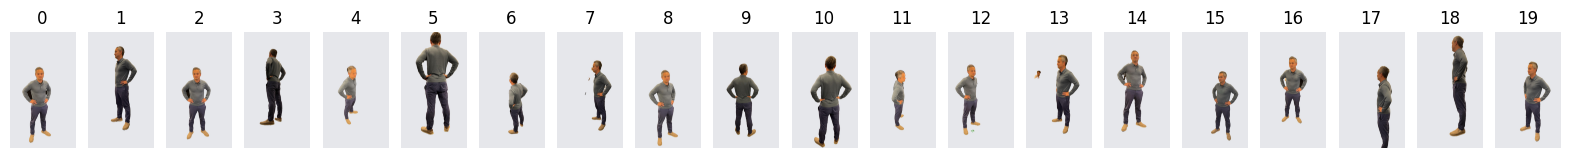

In [23]:
import cv2
import matplotlib.pyplot as plt
import os
import json
import numpy as np

def create_cam_parms(cam_info):
    cams_data = {}
    for cam in cam_info['frames']:
        K = np.zeros((3, 3), dtype=np.float32)
        K[0,0] = cam['fl_x']
        K[1,1] = cam['fl_y']
        K[0,2] = cam['cx']
        K[1,2] = cam['cy']
        K[2,2] = 1.0
        w = cam['w']
        h = cam['h']
        p = np.zeros((5, 1), dtype=np.float64)
        p[0,0] = cam['k1']
        p[1,0] = cam['k2']
        p[2,0] = cam['k3']
        p[3,0] = cam['p1']
        p[4,0] = cam['p2']

        #read extrinsics
        M = np.array(cam['transform_matrix']).astype(np.float32)
        cams_data[cam['file_path'].split('\\')[-1]] = {'K': K, 'M': M, 'width': w, 'height': h, 'distortion':p}
    return cams_data

def load_images_from_folder(folder, cams_data, masked=False, showImg=False, new_recordings=False): 
    images = []
    cams = []
    for filename in os.listdir(folder):
        #load image file
        if filename.endswith(".png") or filename.endswith(".jpg"):
            #search for the corresponding camera info
            #load image file
            if masked: #only load masked images out of all masked and unmasked images, assuming the folder contains both
                if "masked" in filename:
                    img = cv2.cvtColor(cv2.imread(os.path.join(folder, filename)), cv2.COLOR_BGR2RGB)
                    images.append(img)
                    cams.append(cams_data[filename])
            else: #don't care if the image is masked or not, just load it.
                img = cv2.cvtColor(cv2.imread(os.path.join(folder, filename)), cv2.COLOR_BGR2RGB)
                images.append(img)

                if new_recordings: #for new recordings, camera data name does not contain frame id but contain .mp4

                    filename = filename.split('_')
                    filename = '_'.join(filename[:-1]) + '.mp4'

                else:
                    if filename not in cams_data.keys(): #if the image name is not in the camera data, add or remove "_masked" from the name
                        if "masked" in filename:
                            filename = filename.replace("_masked", "")
                        else:
                            namelist = filename.split('_')
                            namelist.insert(2, "masked")
                            filename = '_'.join(namelist)
                cams.append(cams_data[filename])    

    if showImg:#show all images
        length = len(images)
        plt.figure(figsize=(20, 10))
        for i in range(length):
            plt.subplot(1, length, i+1)
            plt.imshow(images[i])
            plt.axis('off')
            #showing image id on top of the image
            plt.title(str(i))
        plt.show()           
    
    return images, cams

frame_id = 5
datapath = "D:/Data/human_body_data/2025-10-08-12-40-41"
#datapath = "D:/Data/human_body_data/Quentin_180_out_of_sync/2025-04-14-16-03-48"
img_path = os.path.join(datapath, "images_masked", f"{frame_id}")
cam_path = os.path.join(datapath, "splatfacto",f"{frame_id}")

with open(os.path.join(cam_path, "transforms.json")) as f:
    cams_info_raw = json.load(f)
cams_data = create_cam_parms(cams_info_raw)
images, cams = load_images_from_folder(img_path, cams_data=cams_data, masked=False, showImg=True, new_recordings=True)


In [24]:
#utility functions for initializing camera settings and reading images
#from lib.rectification import stereo_rectify

def verify_camera_poses(cams_info: list, drawangle=None):

    # Verifies the camera poses by visualizing them.
    def draw_local_axes(pos, va, vb):
        # draw small lines to represent the local axes of the camera
        plt.plot([pos[0], pos[0] + 0.3 * va[0]], [pos[1], pos[1] + 0.3 * va[1]], c="r")
        plt.plot([pos[0], pos[0] + 0.3 * vb[0]], [pos[1], pos[1] + 0.3 * vb[1]], c="b")

    def draw_angles(pos, R, angle=None):
        if angle is not None:
            rot_obj = R_.from_matrix(R)
            # Specify a convention, for example, 'yxz' means:
            #   first a rotation around Y (yaw), then around X (pitch), then around Z (roll)
            yaw, pitch, roll = rot_obj.as_euler("yxz", degrees=True)
            plt.text(pos[0] + 0.2, pos[1], f"Yaw: {yaw:.2f}", fontsize=12, color="black")

    # plot the camera positions in 3D space
    i = 0
    for cam in cams_info:
        t = cam["M"][:3, 3].copy()
        va = cam["M"][::2, 2].copy()[::-1]
        vb = cam["M"][::2, 0].copy()[::-1]
        a, b = t[2], t[0]
        plt.plot(a, b, c="r", marker="*")
        plt.text(a, b, str(i), fontsize=12, color="black")
        draw_local_axes([a, b], va, vb)
        draw_angles([a, b], cam["M"][:3, :3], drawangle)
        i += 1

    plt.axis("equal")
    plt.xlabel("Z-axis")
    plt.ylabel("X-axis")


def correct_camera_poses(cams_info: list):
    # make a copy of the camera poses
    cams_copy = copy.deepcopy(cams_info)
    # change the camera poses to facing inward
    for cam in cams_copy:
        # flip the y and z axis
        cam["M"][:, 1] = -cam["M"][:, 1]
        cam["M"][:, 2] = -cam["M"][:, 2]

    return cams_copy


# transform camera poses to world cam projection matrix
def world_to_camera(cams_info: list):
    # convert the camera poses world to camera matrix

    world_to_camera_matrices = []
    for cam in cams_info:
        # get the camera extrinsic matrix
        R = cam["M"][:3, :3].copy()
        t = cam["M"][:3, 3].copy()

        R_transposed = R.T
        t_new = -R_transposed @ t

        world_to_camera_matrix = np.eye(4)
        world_to_camera_matrix[:3, :3] = R_transposed
        world_to_camera_matrix[:3, 3] = t_new
        world_to_camera_matrices.append(world_to_camera_matrix)
    return world_to_camera_matrices

def pad_image(image, target_size, K, pad_value=[230, 231, 235]):
    """
    Pad the image to the target size with a specific color.
    """
    padded_image = np.full((target_size[0], target_size[1], 3), pad_value, dtype=image.dtype)
    # Compute padding offsets
    y_offset = (target_size[0] - image.shape[0]) // 2
    x_offset = (target_size[1] - image.shape[1]) // 2
    # Place the original image in the center
    padded_image[y_offset:y_offset + image.shape[0], x_offset:x_offset + image.shape[1]] = image

    # Adjust the intrinsic matrix K
    K_pad = K.copy()
    K_pad[0, 2] += (target_size[1] - image.shape[1]) / 2  # Adjust cx
    K_pad[1, 2] += (target_size[0] - image.shape[0]) / 2  # Adjust cy
    return padded_image, K_pad

def extract_rt_from_extrinsic(E):
    """
    Extract the rotation matrix R and translation vector t from a 4x4 extrinsic matrix.
    """
    R = E[:3, :3]
    t = E[:3, 3]
    return R, t

def compute_relative_transform(E1, E2):
    """
    Given two extrinsic matrices (world-to-camera), compute the relative rotation and translation
    from camera 1 to camera 2.
    """
    R1, t1 = extract_rt_from_extrinsic(E1)
    R2, t2 = extract_rt_from_extrinsic(E2)
    R_rel = R2 @ R1.T         # Relative rotation: R2 * inv(R1)
    T_rel = t2 - R_rel @ t1   # Relative translation
    return R_rel, T_rel

def stereo_rectify(cams_info: list, world_cam_extrs: list, cam_ids, alpha=1, scale_factor=1):
    
    E1 = world_cam_extrs[cam_ids[0]]
    E2 = world_cam_extrs[cam_ids[1]]

    # Example intrinsic matrices (these would normally come from calibration).
    K1 = cams_info[cam_ids[0]]['K']
    K2 = cams_info[cam_ids[1]]['K']

    K1 = np.array(K1, dtype=np.float64)
    K2 = np.array(K2, dtype=np.float64)

    # Compute the relative transformation from camera 1 to camera 2.
    R_rel, T_rel = compute_relative_transform(E1, E2)
    R_rel = np.array(R_rel, dtype=np.float64)
    T_rel = np.array(T_rel, dtype=np.float64).reshape(3, 1)

    # Define the image size (width, height).
    width, height = cams_info[cam_ids[0]]['width'], cams_info[cam_ids[0]]['height']
    imageSize = (width, height)

    #if distortion exists, use it here
    if 'distortion' in cams_info[cam_ids[0]]:
        distCoeffs1 = cams_info[cam_ids[0]]['distortion']
        distCoeffs2 = cams_info[cam_ids[1]]['distortion']
    else:
        # Assume no lens distortion (distortion coefficients are zeros).
        distCoeffs1 = np.zeros((5, 1), dtype=np.float64)
        distCoeffs2 = np.zeros((5, 1), dtype=np.float64)
    distCoeffs1 = np.zeros((5, 1), dtype=np.float64)
    distCoeffs2 = np.zeros((5, 1), dtype=np.float64)
    newImageSize = (int(width * scale_factor), int(height * scale_factor))
    # Use OpenCV's stereoRectify to compute the rectification transforms.
    R1_rect, R2_rect, P1_rect, P2_rect, Q, roi1, roi2 = cv2.stereoRectify(
        cameraMatrix1=K1,
        distCoeffs1=distCoeffs1,
        cameraMatrix2=K2,
        distCoeffs2=distCoeffs2,
        imageSize=imageSize,
        R=R_rel,
        T=T_rel,
        flags=cv2.CALIB_ZERO_DISPARITY,
        alpha=alpha,  # alpha=0 will crop the images; adjust as needed.
        newImageSize=newImageSize  # None means the original image size will be used.
    )

    # Display results.
    """print("Rectification rotation for camera 1 (R1_rect):\n", R1_rect)
    print("\nRectification rotation for camera 2 (R2_rect):\n", R2_rect)
    print("\nNew projection matrix for camera 1 (P1_rect):\n", P1_rect)
    print("\nNew projection matrix for camera 2 (P2_rect):\n", P2_rect)
    print("\nDisparity-to-depth mapping matrix (Q):\n", Q)"""

    return R1_rect, R2_rect, P1_rect, P2_rect, Q, roi1, roi2

def stereo_rectify_central_axis(cams_info, world_cam_extrs, cam_ids):
    """
    Rectify two cameras to a common 'central' axis.

    INPUTS
      cams_info: list of dicts with 'K','width','height'
      world_cam_extrs: list of 4x4 world->camera extrinsics (E = [R|t] with x_cam = R x_world + t)
      cam_ids: pair [i,j]

    RETURNS (same contract as your code expects)
      R1_rect, R2_rect, P1_rect, P2_rect, Q
      where exterior code will do `new_extr = R_rect @ old_extr` (3x3 @ 3x4).
    """
    E1 = world_cam_extrs[cam_ids[0]]
    E2 = world_cam_extrs[cam_ids[1]]

    K1 = np.array(cams_info[cam_ids[0]]["K"], dtype=np.float64)
    K2 = np.array(cams_info[cam_ids[1]]["K"], dtype=np.float64)

    # world->camera rotations and translations
    R1_wc = E1[:3, :3].astype(np.float64)
    t1_wc = E1[:3, 3].astype(np.float64)
    R2_wc = E2[:3, :3].astype(np.float64)
    t2_wc = E2[:3, 3].astype(np.float64)

    # camera -> world rotations (useful to get camera axes in WORLD frame)
    C1 = R1_wc.T
    C2 = R2_wc.T

    # camera centers in world coordinates: c = -R.T @ t
    c1_world = -C1 @ t1_wc
    c2_world = -C2 @ t2_wc

    # baseline vector in WORLD coordinates
    baseline_world = c2_world - c1_world
    bl_norm = np.linalg.norm(baseline_world)

    x_axis = baseline_world / bl_norm  # desired rectified x axis (points from cam1->cam2)

    # average camera_to_world orientation (slerp between camera->world rotations)
    slerp = Slerp([0, 1], Rot.from_matrix([C1, C2]))
    C_central = slerp(0.5).as_matrix()

    # optical axis (forward) in WORLD coords. For our frustum convention optical = -Z in camera coords.
    z_guess_world = C_central[:, 2]

    # orthogonalize the forward guess to the baseline (so x and z are orthogonal)
    z_axis = z_guess_world - np.dot(z_guess_world, x_axis) * x_axis
    z_norm = np.linalg.norm(z_axis)
    if z_norm < 1e-9:
        # fallback: pick any vector orthogonal to x_axis
        if abs(x_axis[0]) < abs(x_axis[1]):
            tmp = np.array([1.0, 0.0, 0.0])
        else:
            tmp = np.array([0.0, 1.0, 0.0])
        z_axis = tmp - np.dot(tmp, x_axis) * x_axis
        z_axis /= np.linalg.norm(z_axis)
    else:
        z_axis /= z_norm

    # complete right-handed frame: y = z x x (so x, y, z form RHS with x cross y = z)
    y_axis = np.cross(z_axis, x_axis)
    y_axis /= np.linalg.norm(y_axis)

    # Basis matrix B: columns are rectified axes expressed in WORLD coords:
    # B maps rectified-frame vectors -> world vectors
    B = np.column_stack([x_axis, y_axis, z_axis])  # 3x3

    # R_world_to_rect = B.T maps world vectors -> rectified-frame vectors
    R_world_to_rect = B.T

    # IMPORTANT: the R returned to outside must satisfy
    #   new_extr = R_rect @ old_extr
    # and so new_extr[:3,:3] = (R_rect @ R_wc) must equal R_world_to_rect.
    # From algebra R_rect must be R_world_to_rect @ R_wc.T
    R1_rect = R_world_to_rect @ R1_wc.T  # maps camera1 coords -> rectified coords
    R2_rect = R_world_to_rect @ R2_wc.T  # maps camera2 coords -> rectified coords

    # Projection matrices (use averaged intrinsics)
    f = 0.5 * (K1[0, 0] + K2[0, 0])
    cx = 0.5 * (K1[0, 2] + K2[0, 2])
    cy = 0.5 * (K1[1, 2] + K2[1, 2])

    # baseline expressed in rectified frame
    baseline_rect = R_world_to_rect @ baseline_world
    bx = baseline_rect[0]

    # Standard symmetric P1,P2: left uses [I|0], right has x-shift = -f * baseline_x
    P1_rect = np.array([[f, 0, cx, 0.0], [0, f, cy, 0.0], [0, 0, 1, 0.0]], dtype=np.float64)

    # pixel translation for P2: negative because if cam2 is +x in rect frame we want P2 to have -f*baseline
    P2_rect = np.array([[f, 0, cx, -f * bx], [0, f, cy, 0.0], [0, 0, 1, 0.0]], dtype=np.float64)

    # Build a Q similar to cv2.stereoRectify (for symmetric intrinsics, cx==cx')
    # Tx for Q formula is P2[0,3]/f = -bx
    Tx = P2_rect[0, 3] / f  # equals -bx
    # Use the usual pattern: Q[3,2] = -1/Tx (cv uses -1/Tx)
    # Because Tx is P2[0,3]/f, when P2[0,3] = -f*bx -> Tx = -bx -> -1/Tx = 1/bx
    Q = np.array(
        [[1.0, 0.0, 0.0, -cx], [0.0, 1.0, 0.0, -cy], [0.0, 0.0, 0.0, f], [0.0, 0.0, -1.0 / Tx, 0.0]], dtype=np.float64
    )

    return R1_rect, R2_rect, P1_rect, P2_rect, Q

def read_image_frames(datapath, frame_ids, new_recordings=False):
    images = []
    cams = []
    for frame_id in frame_ids:
        img_path = os.path.join(datapath, "images_masked", f"{frame_id}")
        cam_path = os.path.join(datapath, "splatfacto", f"{frame_id}")

        with open(os.path.join(cam_path, "transforms.json")) as f:
            cams_info_raw = json.load(f)
        cams_data = create_cam_parms(cams_info_raw)
        imgs_i, cams_i = load_images_from_folder(img_path, cams_data=cams_data, masked=False, showImg=False, new_recordings=new_recordings)
        
        images.append(imgs_i)
        cams.append(cams_i)
        print(f"Loaded frame {frame_id} with {len(imgs_i)} images and {len(cams_i)} camera parameters.")
    
    return images, cams

def compute_cam_yaw_pitch(cams):
    yaw_angles = []
    pitch_angles = []
    for cam in cams:
        rot_obj = R_.from_matrix(cam['M'][:3,:3])
        # Specify a convention, for example, 'yxz' means:
        #   first a rotation around Y (yaw), then around X (pitch), then around Z (roll)
        yaw, pitch, roll = rot_obj.as_euler('yxz', degrees=True)
        yaw_angles.append(yaw)
        pitch_angles.append(pitch)
    return yaw_angles, pitch_angles

def sort_by_yaw(cams):
    yaw_angles,_ = compute_cam_yaw_pitch(cams)
    #sort indices based on yaw angles
    sorted_indices = np.argsort(yaw_angles)
   
    #return sorted indices and yaw angles
    yaw_angles_sorted = [yaw_angles[i] for i in sorted_indices]
    
    return sorted_indices, yaw_angles_sorted

def get_cams_rectified(cams, sorted_indices, alpha=1, scale_factor=1):

    #correct camera poses by rotating around the x axis by 180 degrees
    cams_copy = correct_camera_poses(cams)
    world_to_camera_matrices = world_to_camera(cams_copy)

    cams_rectified = []
    for i in range(len(sorted_indices)-1):

        #R1_rect, R2_rect, P1_rect, P2_rect, Q, roi1, roi2 = stereo_rectify(cams, world_to_camera_matrices, [sorted_indices[i], sorted_indices[i+1]], alpha=alpha, scale_factor=scale_factor)
        
        R1_rect, R2_rect, P1_rect, P2_rect, *_ = stereo_rectify_central_axis(
            cams, 
            world_to_camera_matrices,
            [sorted_indices[i], sorted_indices[i + 1]],
        )

        new_extr1 = R1_rect @ world_to_camera_matrices[sorted_indices[i]][:3,:] #oringally new_extr0 = R0 @ extr0
        new_extr1 = np.vstack([new_extr1, np.array([[0, 0, 0, 1]])])      
        new_intr1 = P1_rect[:3, :3]
        
        new_extr2 = R2_rect @ world_to_camera_matrices[sorted_indices[i+1]][:3,:]
        new_intr2 = P2_rect[:3, :3]
        new_extr2 = np.vstack([new_extr2, np.array([[0, 0, 0, 1]])])


        # Get the intrinsic matrices
        K1 = cams[sorted_indices[i]]['K']
        K2 = cams[sorted_indices[i+1]]['K']

        
        disp_shape = int(cams[sorted_indices[i]]['width']*scale_factor), int(cams[sorted_indices[i]]['height']*scale_factor)

        # Rectify the images
        map1x, map1y = cv2.initUndistortRectifyMap(K1, np.zeros((5, 1)), R1_rect, P1_rect, disp_shape, cv2.CV_32FC1)
        map2x, map2y = cv2.initUndistortRectifyMap(K2, np.zeros((5, 1)), R2_rect, P2_rect, disp_shape, cv2.CV_32FC1)


        cams_rectified.append({'left':{
            'M': new_extr1.astype(np.float32),
            'K': new_intr1.astype(np.float32),
            'M_original': world_to_camera_matrices[sorted_indices[i]].astype(np.float32),
            'K_original': K1.astype(np.float32),
            'P': P1_rect,
            'R': R1_rect,
            'mapx': map1x,
            'mapy': map1y,
        }, 'right':{
            'M': new_extr2.astype(np.float32),
            'K': new_intr2.astype(np.float32),
            'M_original': world_to_camera_matrices[sorted_indices[i+1]].astype(np.float32),
            'K_original': K2.astype(np.float32),
            'P': P2_rect,
            'R': R2_rect,
            'mapx': map2x,
            'mapy': map2y,
        }})
    return cams_rectified

def plot_cameras_3d(cams): #use open3d to plot cameras positions
    import open3d as o3d

    camera_pcds = []
    for cam in cams:
        #create camera point cloud
        camera_pcds.append(list(cam['M'][:3, 3].astype(float).T))

    camera_pcd = o3d.geometry.PointCloud()
    camera_pcd.points = o3d.utility.Vector3dVector(camera_pcds)
    # Visualize all camera point clouds
    vis = o3d.visualization.Visualizer()
    vis.create_window()
    vis.add_geometry(camera_pcd)
    opt = vis.get_render_option()
    opt.point_size = 10.0  # Increase point size (default is 1.0)
    vis.run()
    vis.destroy_window()


In [33]:
from torch.utils.data import Dataset

class StreamData(Dataset): #rectification is done in this dataclass. Might be more plaussible to do it in the model class.
    def __init__(self, opt=None): #
        self.opt = opt

    def get_data_from_stream(self, img_pair, cam_pair, rectify=True, batch_size=1, background=(0, 0, 0)): #may nextend to larger batch sizes
        if rectify:
            rectified_img1 = cv2.remap(img_pair[0].astype(np.float32), 
                                       cam_pair['left']['mapx'], 
                                       cam_pair['left']['mapy'], 
                                       interpolation=cv2.INTER_LINEAR, 
                                       borderValue=background)
            rectified_img2 = cv2.remap(img_pair[1].astype(np.float32), 
                                       cam_pair['right']['mapx'], 
                                       cam_pair['right']['mapy'], 
                                       interpolation=cv2.INTER_LINEAR, 
                                       borderValue=background)
        else:
            rectified_img1 = img_pair[0].copy()
            rectified_img2 = img_pair[1].copy()
            
        #create masks
        xyz_mask_l = np.ones_like(rectified_img1[:, :, 0]) * 255
        xyz_mask_l[(np.abs(rectified_img1[...,0]  - background[0]) < 30) & (np.abs(rectified_img1[...,1]  - background[1]) < 30) & (np.abs(rectified_img1[...,2]  - background[2]) < 30)] = 0
        xyz_mask_r = np.ones_like(rectified_img2[:, :, 0]) * 255
        xyz_mask_r[(np.abs(rectified_img2[...,0]  - background[0]) < 30) & (np.abs(rectified_img2[...,1]  - background[1]) < 30) & (np.abs(rectified_img2[...,2]  - background[2]) < 30)] = 0

        #apply erosion to masks to shrink valid regions slightly and remove noise
        kernel = np.ones((3, 3), np.uint8)
        xyz_mask_l = cv2.erode(xyz_mask_l.astype(np.uint8), kernel, iterations=1)
        xyz_mask_r = cv2.erode(xyz_mask_r.astype(np.uint8), kernel, iterations=1)

        
        item = self.get_test_item_memory(img_pair= (rectified_img1, rectified_img2),
                                         msk_pair=(xyz_mask_l, xyz_mask_r),
                                         K_pair=(cam_pair['left']['K'], cam_pair['right']['K']),
                                         M_pair=(cam_pair['left']['M'], cam_pair['right']['M']),
                                         K_pair_ori=(cam_pair['left']['K_original'], cam_pair['right']['K_original']),
                                         M_pair_ori=(cam_pair['left']['M_original'], cam_pair['right']['M_original']))

        return item


    def get_test_item_memory(self, img_pair, msk_pair, K_pair, M_pair, K_pair_ori=None, M_pair_ori=None, frameid = '0', require_mask=True):
        # img_pair: [img0, img1], msk_pair: [msk0, msk1], K_pair: [K0, K1], M_pair: [M0, M1]

        lmain_intr_ori, rmain_intr_ori = (K_pair_ori[0], K_pair_ori[1]) if K_pair_ori is not None else (K_pair[0], K_pair[1])
        lmain_extr_ori, rmain_extr_ori = (M_pair_ori[0], M_pair_ori[1]) if M_pair_ori is not None else (M_pair[0], M_pair[1])

        mask_0, pts_0 = None, None
        mask_1, pts_1 = None, None
        left_0, right_0, face_0 = torch.zeros(21,2),  torch.zeros(21,2),  torch.zeros(19,3)
        left_1, right_1, face_1 = torch.zeros(21,2),  torch.zeros(21,2),  torch.zeros(19,3)

        if require_mask:
            mask_0 = np.stack([msk_pair[0], msk_pair[0], msk_pair[0]], axis=-1)
            mask_1 = np.stack([msk_pair[1], msk_pair[1], msk_pair[1]], axis=-1)


        camera = {
            'intr0': K_pair[0],
            'intr1': K_pair[1],
            'extr0': M_pair[0],
            'extr1': M_pair[1],
        }

        stereo_data = {
            'img0': img_pair[0],
            'mask0': mask_0,
            'left0': left_0,
            'right0': right_0,
            'face0': face_0,
            'img1': img_pair[1],
            'mask1': mask_1,
            'camera': camera,
            'left1': left_1,
            'right1': right_1,
            'face1': face_1,
        }

        dict_tensor = self.stereo_to_dict_tensor(stereo_data, frameid)


        dict_tensor['lmain']['intr_ori'] = torch.FloatTensor(lmain_intr_ori)
        dict_tensor['rmain']['intr_ori'] = torch.FloatTensor(rmain_intr_ori)
        dict_tensor['lmain']['extr_ori'] = torch.FloatTensor(lmain_extr_ori)
        dict_tensor['rmain']['extr_ori'] = torch.FloatTensor(rmain_extr_ori)

        #img_len = 2048 if self.opt.use_hr_img else 1024
        img_len=1024
        novel_dict = {
            'height': torch.IntTensor([img_len]),
            'width': torch.IntTensor([img_len])
        }

        dict_tensor.update({
            'novel_view': novel_dict
        })

        return dict_tensor

    def stereo_to_dict_tensor(self, stereo_data, subject_name):
        img_tensor, mask_tensor = [], []
        for (img_view, mask_view) in [('img0', 'mask0'), ('img1', 'mask1')]:
            img = torch.from_numpy(stereo_data[img_view]).permute(2, 0, 1)

            #comment the following line out because unimatch assumes a different pixel distribution
            #img = 2 * (img / 255.0) - 1.0
            
            mask = torch.from_numpy(stereo_data[mask_view]).permute(2, 0, 1).float()
            mask = mask.mul_(1.0 / 255.0)

            img = img.mul_(mask)

            #need to change the following two lines for green background
            mask[mask < 0.5] = 0.0 
            mask[mask >= 0.5] = 1.0

            img_tensor.append(img)
            mask_tensor.append(mask)

        # Convert intrinsics/extrinsics directly without intermediate copies
        camera_intr0 = torch.from_numpy(stereo_data['camera']['intr0']).float()
        camera_intr1 = torch.from_numpy(stereo_data['camera']['intr1']).float()
        camera_extr0 = torch.from_numpy(stereo_data['camera']['extr0']).float()
        camera_extr1 = torch.from_numpy(stereo_data['camera']['extr1']).float()


        lmain_data = {
            'img': img_tensor[0],
            'img_ori': img_tensor[0],
            'mask': mask_tensor[0],
            'intr': camera_intr0,
            'ref_intr': camera_intr1,
            'extr': camera_extr0,
            'left': stereo_data['left0'],
            'right': stereo_data['right0'],
            'face': stereo_data['face0'],
        }

        rmain_data = {
            'img': img_tensor[1],
            'img_ori': img_tensor[1],
            'mask': mask_tensor[1],
            'intr': camera_intr1,
            'ref_intr': camera_intr0,
            'extr': camera_extr1 ,
            'left': stereo_data['left1'],
            'right': stereo_data['right1'],
            'face': stereo_data['face1'],
        }

        if 'flow0' in stereo_data:
            flow_tensor, valid_tensor = [], []
            for (flow_view, valid_view) in [('flow0', 'valid0'), ('flow1', 'valid1')]:
                flow = torch.from_numpy(stereo_data[flow_view])
                flow = torch.unsqueeze(flow, dim=0)
                flow_tensor.append(flow)

                valid = torch.from_numpy(stereo_data[valid_view])
                valid = torch.unsqueeze(valid, dim=0)
                valid = valid / 255.0
                valid_tensor.append(valid)

            lmain_data['flow'], lmain_data['valid'] = flow_tensor[0], valid_tensor[0]
            rmain_data['flow'], rmain_data['valid'] = flow_tensor[1], valid_tensor[1]

        if 'depth0' in stereo_data:
            depth_tensor = []
            for depth_view in ['depth0', 'depth1']:
                depth = torch.from_numpy(stereo_data[depth_view])
                depth = torch.unsqueeze(depth, dim=0)
                depth_tensor.append(depth)

            lmain_data['depth'] = depth_tensor[0]
            rmain_data['depth'] = depth_tensor[1]

        return {'name': subject_name, 'lmain': lmain_data, 'rmain': rmain_data}
    
    def showimg(self, item):

        plt.subplot(1, 2, 1)
        #plt.imshow((item['lmain']['img'].permute(1, 2, 0).cpu().numpy()+1.0)/2.0)
        plt.imshow(item['lmain']['img_ori'].permute(1, 2, 0).cpu().numpy()/255.0)
        plt.title('Left Image')

        plt.subplot(1, 2, 2)
        #plt.imshow((item['rmain']['img'].permute(1, 2, 0).cpu().numpy()+1.0)/2.0)
        plt.imshow(item['rmain']['img_ori'].permute(1, 2, 0).cpu().numpy()/255.0)
        plt.title('Right Image')

        plt.show()

In [34]:
import copy

K1 = cams[16]['K']
K2 = cams[15]['K']
img_width, img_height = 1080, 1920
img1, K1 = pad_image(images[16], (img_height, img_height+400), K1)
img2, K2 = pad_image(images[15], (img_height, img_height+400), K2)
cams_padded1 = copy.deepcopy(cams[16])
cams_padded1['K'] = K1
cams_padded1['width'] = img1.shape[1]
cams_padded1['height'] = img1.shape[0]
cams_padded2 = copy.deepcopy(cams[15])
cams_padded2['K'] = K2
cams_padded2['width'] = img2.shape[1]
cams_padded2['height'] = img2.shape[0]

cams_rectified = get_cams_rectified([cams_padded1,cams_padded2], [0, 1], 0.5, 1)

In [35]:
stream = StreamData()
item = stream.get_data_from_stream((img1, img2), cams_rectified[0], rectify=True, background=(230, 231, 235))

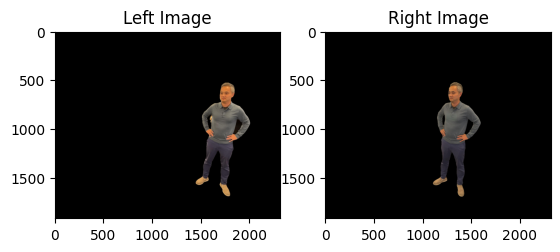

In [36]:
stream.showimg(item)

In [37]:
from config.transformer_human_config import ConfigStereoHuman as config
cfg = config()
cfg_for_test = os.path.join('./config', 'small_cap.yaml')
cfg.load(cfg_for_test)
cfg = cfg.get_cfg()
cfg.defrost()
cfg.batch_size = 1
cfg.dataset.use_processed_data = False
cfg.restore_ckpt = 'pretrained/GPS-GS_stage2_final.pth'
cfg.unimatch.unimatch_ckpt = 'unimatch/pretrained/gmstereo-scale2-regrefine3-resumeflowthings-middleburyfthighres-a82bec03.pth'
cfg.freeze()
renderer = StereoHumanRender(cfg, phase='test')

Loaded checkpoint from pretrained/GPS-GS_stage2_final.pth


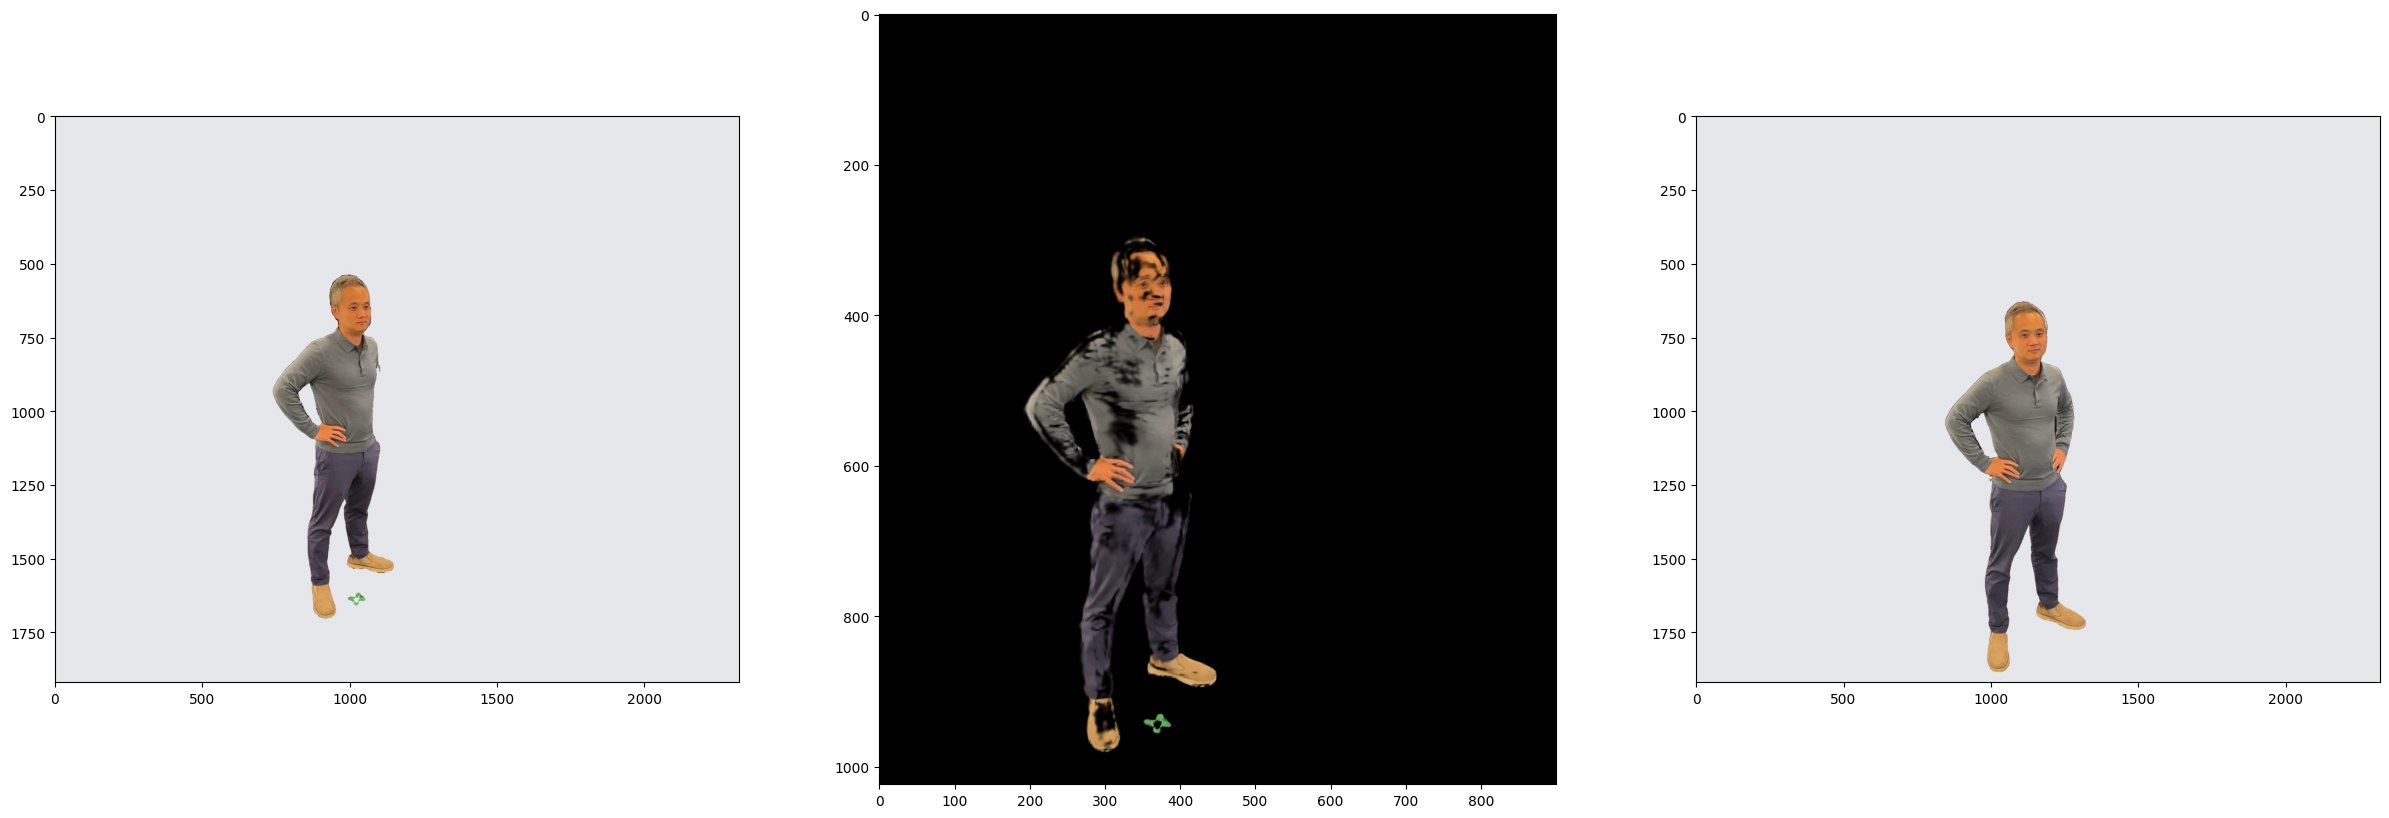

In [38]:
renderer.pred_bidir_disp = True

K1 = cams[12]['K']
K2 = cams[8]['K']
img1, K1 = pad_image(images[12], (img_height, img_height+400), K1)
img2, K2 = pad_image(images[8], (img_height, img_height+400), K2)
cams_padded1 = copy.deepcopy(cams[12])
cams_padded1['K'] = K1
cams_padded1['width'] = img1.shape[1]
cams_padded1['height'] = img1.shape[0]
cams_padded2 = copy.deepcopy(cams[8])
cams_padded2['K'] = K2
cams_padded2['width'] = img2.shape[1]
cams_padded2['height'] = img2.shape[0]


cams_rectified = get_cams_rectified([cams_padded1,cams_padded2], [0, 1], 0.5, 1)
item = stream.get_data_from_stream((img1, img2), cams_rectified[0], rectify=True, background=(230, 231, 235))
data, novel_view = renderer.get_novel_view(item, ratio=0.5)
imgl = (data['lmain']['img'].cpu()[0].numpy().transpose(1,2,0).copy() + 1)/2
imgr = (data['rmain']['img'].cpu()[0].numpy().transpose(1,2,0).copy() + 1)/2  
novel = data['novel_view']['img_pred'].cpu()[0].numpy().transpose(1,2,0).copy()
#novel = novel_view
#result = np.concatenate([orig_img1[:,100:1000,:], novel[:,100:1000,:], orig_img2[:,100:1000,:]], axis=1)
plt.figure(figsize=(30,10))
plt.subplot(1,3,1)
plt.imshow(img1)
plt.subplot(1,3,2)
plt.imshow(novel[:,100:1000,:])
plt.subplot(1,3,3)
plt.imshow(img2)

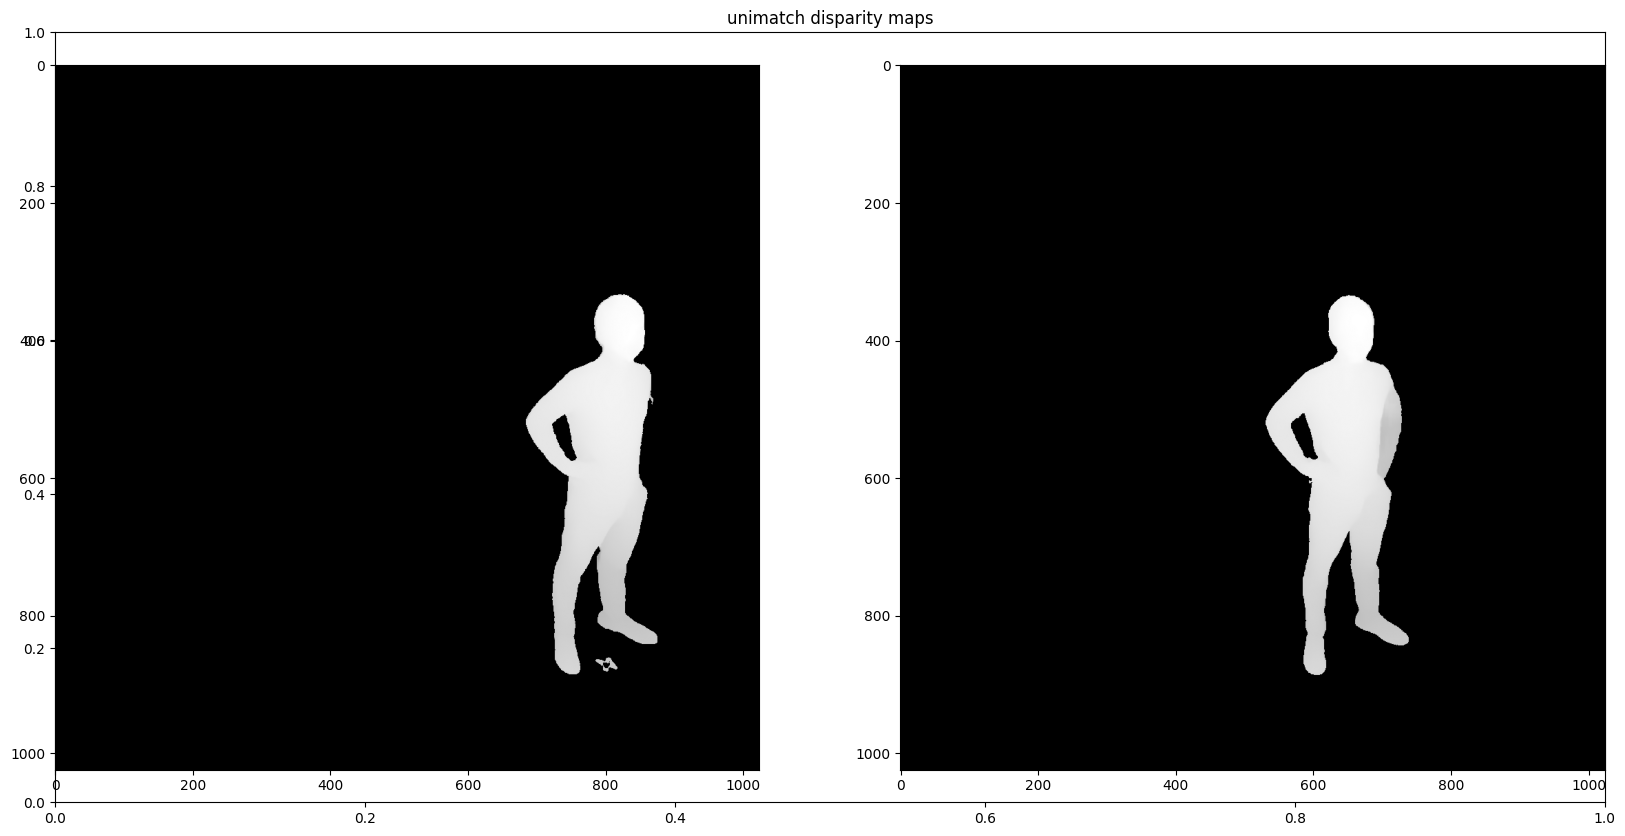

In [39]:
renderer.show_intermediate_results(data)